# Feature Engineering

Machine Learning models cannot read English words. They need numbers. Here, we use TF-IDF to convert cleaned text into a matrix of numerical features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import show_top_ngrams_by_class, add_basic_meta_features, plot_dimensionality_reduction, save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


load cleaned text

In [3]:
processed_train = pd.read_csv(r'data/processed/processed_train.csv', dtype=str, quoting=0)
processed_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,great camra dx6340 year love picture good 35m ...
1,1,not so great,I'm using this book in an introductory organic...,570,88,not great using book introductory organic spec...
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,inaccurate disappointing read first chapter bo...
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,equus 3340 feel cheaply made battery contact r...
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,awesome sheet love sheet sleek smooth really c...


In [4]:
processed_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 79972 entries, 0 to 79971
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   review_target              79972 non-null  str  
 1   review_title               79972 non-null  str  
 2   review_content             79972 non-null  str  
 3   review_content_char_count  79972 non-null  str  
 4   review_content_word_count  79972 non-null  str  
 5   review_content_cleaned     79972 non-null  str  
dtypes: str(6)
memory usage: 3.7 MB


top unigrams, bigrams, and trigrams per class

In [5]:
feat_eng_train = processed_train.copy()

Top unigrams for class 1 and 2 of cleaned review

--- Top unigrams for class 1 ---
[('book', np.int64(23758)), ('like', np.int64(12155)), ('time', np.int64(10224)), ('good', np.int64(9714)), ('movie', np.int64(8472)), ('product', np.int64(7075)), ('work', np.int64(7052)), ('read', np.int64(6978)), ('buy', np.int64(6451)), ('really', np.int64(6243)), ('money', np.int64(6084)), ('great', np.int64(5502)), ('better', np.int64(5419)), ('make', np.int64(5367)), ('bad', np.int64(5279))]



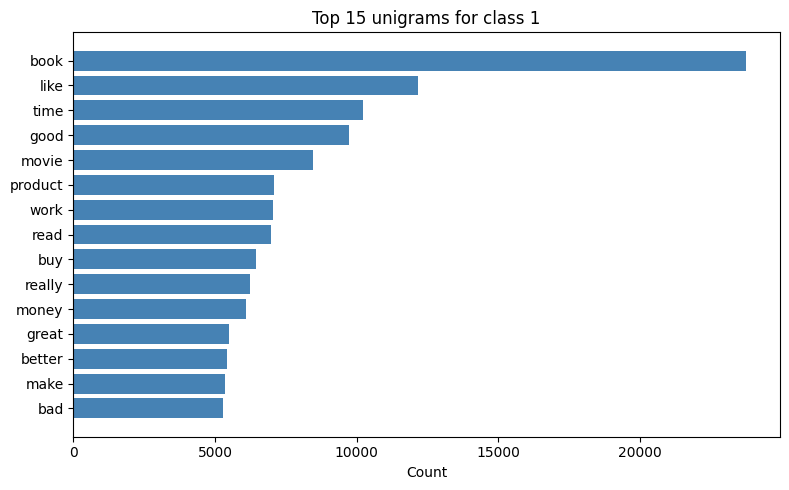

--- Top unigrams for class 2 ---
[('book', np.int64(25730)), ('great', np.int64(18781)), ('good', np.int64(13578)), ('like', np.int64(11231)), ('love', np.int64(9286)), ('read', np.int64(9168)), ('time', np.int64(8808)), ('movie', np.int64(7345)), ('best', np.int64(6904)), ('really', np.int64(6601)), ('work', np.int64(6191)), ('album', np.int64(6066)), ('cd', np.int64(6065)), ('year', np.int64(5538)), ('make', np.int64(5433))]



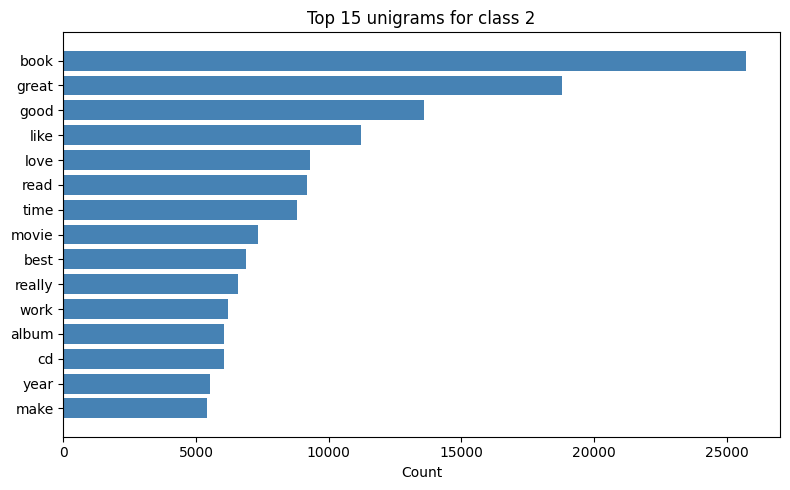

{'1': {(1, 1): [('book', np.int64(23758)),
   ('like', np.int64(12155)),
   ('time', np.int64(10224)),
   ('good', np.int64(9714)),
   ('movie', np.int64(8472)),
   ('product', np.int64(7075)),
   ('work', np.int64(7052)),
   ('read', np.int64(6978)),
   ('buy', np.int64(6451)),
   ('really', np.int64(6243)),
   ('money', np.int64(6084)),
   ('great', np.int64(5502)),
   ('better', np.int64(5419)),
   ('make', np.int64(5367)),
   ('bad', np.int64(5279))]},
 '2': {(1, 1): [('book', np.int64(25730)),
   ('great', np.int64(18781)),
   ('good', np.int64(13578)),
   ('like', np.int64(11231)),
   ('love', np.int64(9286)),
   ('read', np.int64(9168)),
   ('time', np.int64(8808)),
   ('movie', np.int64(7345)),
   ('best', np.int64(6904)),
   ('really', np.int64(6601)),
   ('work', np.int64(6191)),
   ('album', np.int64(6066)),
   ('cd', np.int64(6065)),
   ('year', np.int64(5538)),
   ('make', np.int64(5433))]}}

In [6]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(1, 1), top_k=15)

## Top Unigrams Analysis

The top unigrams reveal the most frequent single words in positive (class 1) and negative (class 2) reviews. Positive reviews often contain words like "great", "good", "love", and "best", indicating strong approval. Negative reviews feature words like "bad", "worst", "terrible", and "disappointed", showing dissatisfaction. This analysis helps identify key sentiment indicators and potential features for the model.

Top bigrams for class 1 and 2 of cleaned review

--- Top bigrams for class 1 ---
[('waste money', np.int64(1986)), ('waste time', np.int64(1204)), ('read book', np.int64(1063)), ('year old', np.int64(942)), ('save money', np.int64(808)), ('look like', np.int64(716)), ('book read', np.int64(711)), ('sound like', np.int64(661)), ('customer service', np.int64(557)), ('year ago', np.int64(504)), ('poor quality', np.int64(496)), ('reading book', np.int64(441))]



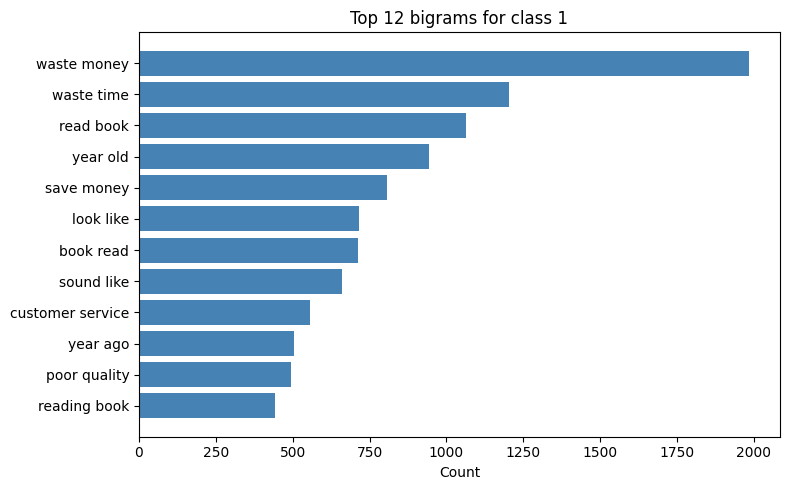

--- Top bigrams for class 2 ---
[('read book', np.int64(1574)), ('year old', np.int64(1138)), ('highly recommend', np.int64(1133)), ('book read', np.int64(1066)), ('great book', np.int64(993)), ('work great', np.int64(717)), ('year ago', np.int64(698)), ('good book', np.int64(669)), ('recommend book', np.int64(607)), ('book great', np.int64(594)), ('great product', np.int64(572)), ('long time', np.int64(572))]



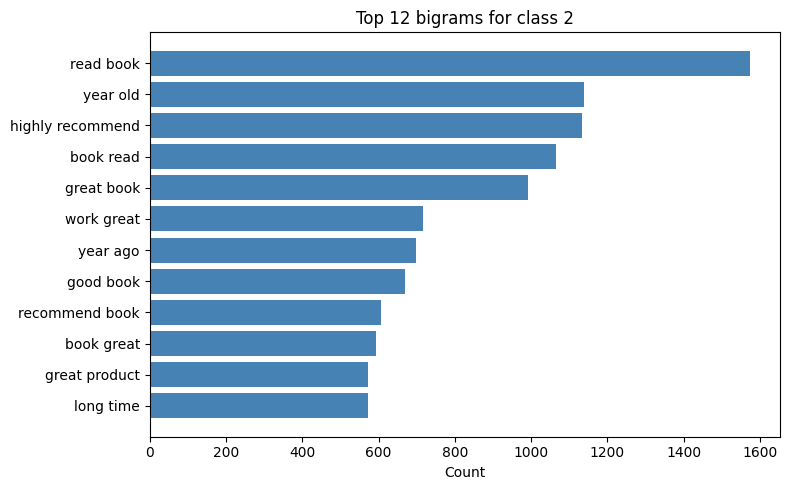

{'1': {(2, 2): [('waste money', np.int64(1986)),
   ('waste time', np.int64(1204)),
   ('read book', np.int64(1063)),
   ('year old', np.int64(942)),
   ('save money', np.int64(808)),
   ('look like', np.int64(716)),
   ('book read', np.int64(711)),
   ('sound like', np.int64(661)),
   ('customer service', np.int64(557)),
   ('year ago', np.int64(504)),
   ('poor quality', np.int64(496)),
   ('reading book', np.int64(441))]},
 '2': {(2, 2): [('read book', np.int64(1574)),
   ('year old', np.int64(1138)),
   ('highly recommend', np.int64(1133)),
   ('book read', np.int64(1066)),
   ('great book', np.int64(993)),
   ('work great', np.int64(717)),
   ('year ago', np.int64(698)),
   ('good book', np.int64(669)),
   ('recommend book', np.int64(607)),
   ('book great', np.int64(594)),
   ('great product', np.int64(572)),
   ('long time', np.int64(572))]}}

In [7]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(2, 2), top_k=12)

## Top Bigrams Analysis

Bigrams (two-word phrases) provide more context than unigrams. Positive reviews show phrases like "highly recommend", "great product", and "love it", while negative ones include "waste money", "poor quality", and "not worth". These combinations capture nuanced sentiments and can improve model accuracy by considering word relationships.

Top trigrams for class 1 and 2 of cleaned review

--- Top 3-3grams for class 1 ---
[('waste time money', np.int64(291)), ('save money buy', np.int64(124)), ('worst book read', np.int64(120)), ('worst movie seen', np.int64(101)), ('total waste money', np.int64(95)), ('waste money time', np.int64(89)), ('complete waste money', np.int64(88)), ('complete waste time', np.int64(73)), ('waste money bought', np.int64(62)), ('wish read review', np.int64(59)), ('waste money buy', np.int64(57)), ('year old son', np.int64(57))]



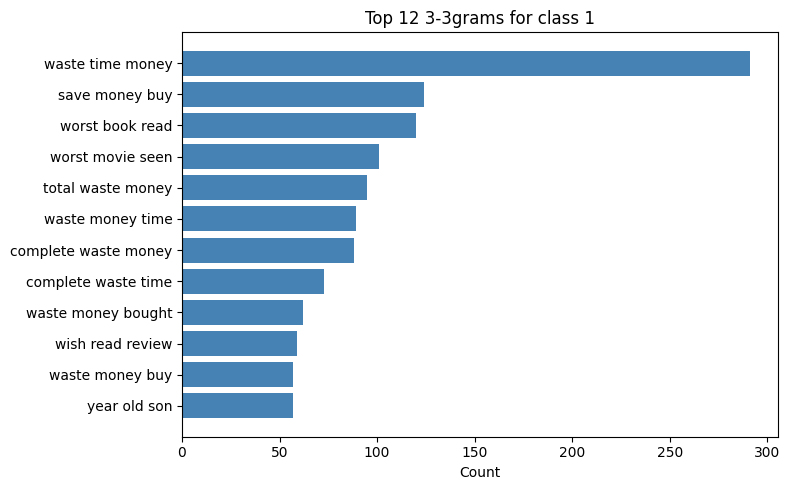

--- Top 3-3grams for class 2 ---
[('highly recommend book', np.int64(196)), ('best book read', np.int64(177)), ('year old son', np.int64(114)), ('book read book', np.int64(82)), ('year old daughter', np.int64(81)), ('book easy read', np.int64(73)), ('really enjoyed book', np.int64(71)), ('year old love', np.int64(69)), ('book great book', np.int64(64)), ('highly recommend product', np.int64(61)), ('love love love', np.int64(61)), ('great book read', np.int64(59))]



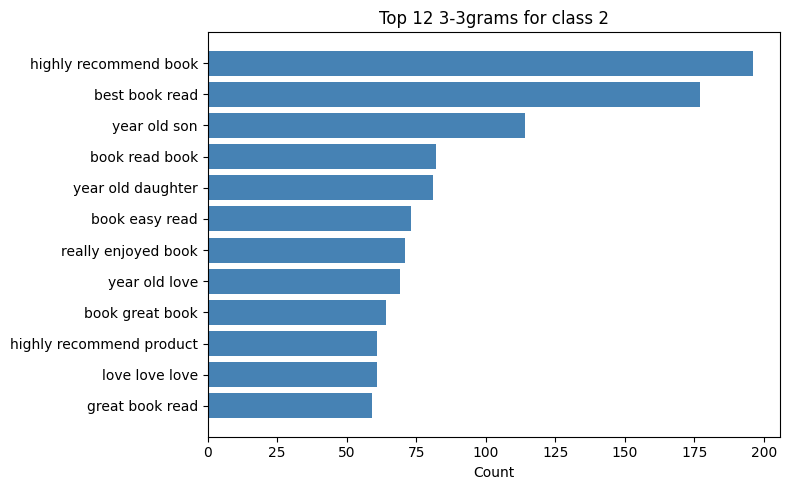

{'1': {(3, 3): [('waste time money', np.int64(291)),
   ('save money buy', np.int64(124)),
   ('worst book read', np.int64(120)),
   ('worst movie seen', np.int64(101)),
   ('total waste money', np.int64(95)),
   ('waste money time', np.int64(89)),
   ('complete waste money', np.int64(88)),
   ('complete waste time', np.int64(73)),
   ('waste money bought', np.int64(62)),
   ('wish read review', np.int64(59)),
   ('waste money buy', np.int64(57)),
   ('year old son', np.int64(57))]},
 '2': {(3, 3): [('highly recommend book', np.int64(196)),
   ('best book read', np.int64(177)),
   ('year old son', np.int64(114)),
   ('book read book', np.int64(82)),
   ('year old daughter', np.int64(81)),
   ('book easy read', np.int64(73)),
   ('really enjoyed book', np.int64(71)),
   ('year old love', np.int64(69)),
   ('book great book', np.int64(64)),
   ('highly recommend product', np.int64(61)),
   ('love love love', np.int64(61)),
   ('great book read', np.int64(59))]}}

In [8]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(3, 3), top_k=12)

## Top Trigrams Analysis

Trigrams (three-word phrases) offer even deeper insights into review sentiments. Positive examples include "one of the best", "highly recommend this product", and "love this item", whereas negative ones feature "waste of money", "not worth the price", and "poor customer service". These longer phrases can distinguish subtle differences in sentiment expression.

Basic meta-features

In [9]:
feat_eng_train = add_basic_meta_features(feat_eng_train, text_col='review_content')
feat_eng_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned,review_content_exclamation_count,review_content_question_count,review_content_punctuation_count,review_content_avg_word_length,review_content_uppercase_count,review_content_uppercase_ratio
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,great camra dx6340 year love picture good 35m ...,0,0,14,4.435185,455,0.776451
1,1,not so great,I'm using this book in an introductory organic...,570,88,not great using book introductory organic spec...,0,0,12,5.488636,4,0.007018
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,inaccurate disappointing read first chapter bo...,0,0,5,4.375000,3,0.014019
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,equus 3340 feel cheaply made battery contact r...,0,0,2,4.705882,2,0.010363
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,awesome sheet love sheet sleek smooth really c...,1,0,9,4.236842,4,0.020202


In [10]:
feat_eng_train = add_basic_meta_features(feat_eng_train, text_col='review_title')
feat_eng_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned,review_content_exclamation_count,review_content_question_count,review_content_punctuation_count,review_content_avg_word_length,review_content_uppercase_count,review_content_uppercase_ratio,review_title_exclamation_count,review_title_question_count,review_title_punctuation_count,review_title_word_count,review_title_avg_word_length,review_title_uppercase_count,review_title_uppercase_ratio
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,great camra dx6340 year love picture good 35m ...,0,0,14,4.435185,455,0.776451,0,0,0,2,5.000000,10,0.909091
1,1,not so great,I'm using this book in an introductory organic...,570,88,not great using book introductory organic spec...,0,0,12,5.488636,4,0.007018,0,0,0,3,3.333333,0,0.000000
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,inaccurate disappointing read first chapter bo...,0,0,5,4.375000,3,0.014019,0,0,0,3,8.666667,1,0.035714
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,equus 3340 feel cheaply made battery contact r...,0,0,2,4.705882,2,0.010363,0,0,0,2,4.500000,1,0.100000
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,awesome sheet love sheet sleek smooth really c...,1,0,9,4.236842,4,0.020202,1,0,1,2,7.000000,0,0.000000


correlation with target

Convert target to numeric for correlation (fall back to category codes)

In [11]:
meta_cols= ['review_content_char_count', 'review_content_word_count', 'review_content_exclamation_count', 'review_content_question_count', 'review_content_punctuation_count', 'review_content_avg_word_length', 'review_content_uppercase_count', 'review_content_uppercase_ratio', 'review_title_exclamation_count', 'review_title_question_count', 'review_title_punctuation_count', 'review_title_word_count', 'review_title_avg_word_length', 'review_title_uppercase_count', 'review_title_uppercase_ratio']
try:
    target_numeric = pd.to_numeric(feat_eng_train['review_target'], errors='coerce')
    if target_numeric.isna().sum() > len(target_numeric) * 0.5:
        target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    else:
        target_numeric = target_numeric.fillna(0)
except Exception:
    target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    
corrs = {col: pd.Series(feat_eng_train[col]).corr(target_numeric) for col in meta_cols}
corr_series = pd.Series(corrs).sort_values(ascending=False)
print('Correlations between meta-features and target:')
print(corr_series)

Correlations between meta-features and target:
review_title_exclamation_count      0.031584
review_content_exclamation_count    0.027933
review_content_avg_word_length      0.013098
review_title_uppercase_ratio        0.004225
review_content_uppercase_ratio     -0.000912
review_title_uppercase_count       -0.001417
review_title_avg_word_length       -0.006423
review_content_uppercase_count     -0.019469
review_title_word_count            -0.021987
review_title_punctuation_count     -0.037998
review_content_char_count          -0.067318
review_content_punctuation_count   -0.069328
review_title_question_count        -0.070542
review_content_word_count          -0.071107
review_content_question_count      -0.090043
dtype: float64


`question_count (-0.190)`: `negative correlation`.    
This means that the `more questions` there are in the review, the more likely it is that the review will be `negative` (close to 0).

`word_count (-0.122)` & `char_count (-0.116)`: `negative correlation`.   
The `longer the review`, the more likely it is to be `negative`.

`uppercase_ratio (0.111)` & `uppercase_count (0.084)`: `positive correlation` (positive but weak).    
The `more capital letters`, the `more positive` the review tends to be.

`avg_word_length (-0.006)` & `punctuation_count (-0.018)`: These numbers are very close to zero.    
This means that these `features are almost useless` and do `not influence` whether the `review is positive or negative`.

ِApply fit and transform using TF-IDF for train dataset

In [12]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=50000, 
                                   min_df=3, max_df=0.9)
X_train_tfidf = tfidf_vectorizer.fit_transform(feat_eng_train['review_content_cleaned'].astype(str))
print('Train TF-IDF shape:', X_train_tfidf.shape)

Train TF-IDF shape: (79972, 50000)


Visualize separability using dimensionality reduction (PCA and TSNE) for train dataset

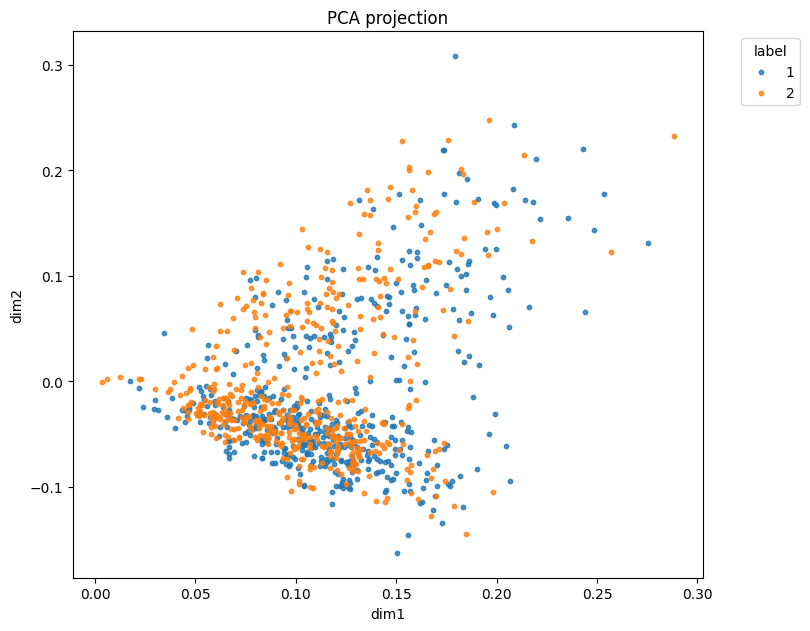

array([[ 0.09676522, -0.04062224],
       [ 0.16508315, -0.09334259],
       [ 0.14646986, -0.05918146],
       ...,
       [ 0.10580088,  0.06846031],
       [ 0.07783006, -0.01748618],
       [ 0.08817249, -0.04936131]], shape=(1000, 2))

In [13]:
plot_dimensionality_reduction(X_train_tfidf, feat_eng_train['review_target'], method='PCA')

## PCA Visualization on Training Data

The PCA plot reduces the high-dimensional TF-IDF features to 2D space. While there's some overlap, we can see clustering where positive reviews (likely blue) tend to group separately from negative ones (red). This indicates that the TF-IDF vectorization captures meaningful differences in sentiment, providing a foundation for classification models.

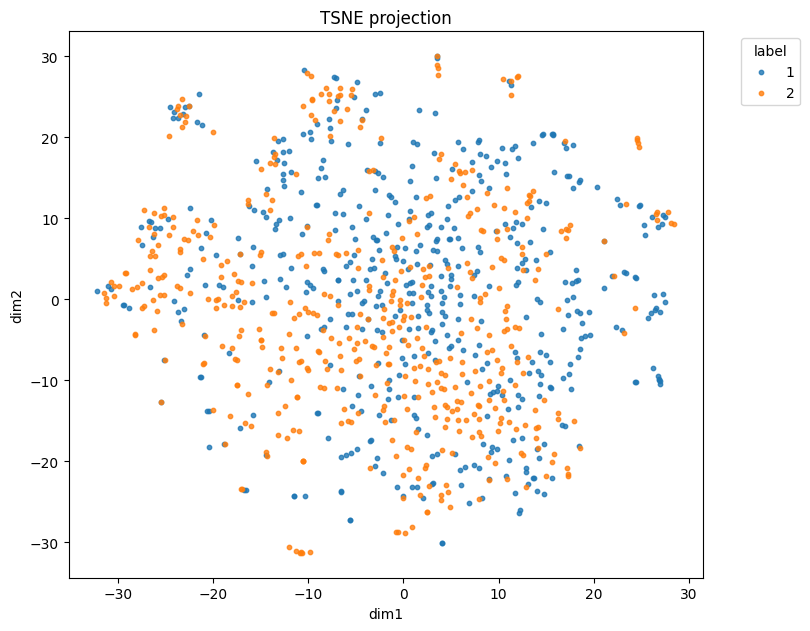

array([[  6.212075  ,  14.105519  ],
       [ -7.743282  ,  -2.4703686 ],
       [-16.37141   ,  12.215105  ],
       ...,
       [  7.122952  , -11.543503  ],
       [  4.0669727 ,  -0.39957052],
       [ -6.5636044 , -23.73045   ]], shape=(1000, 2), dtype=float32)

In [14]:
plot_dimensionality_reduction(X_train_tfidf, feat_eng_train['review_target'], method='TSNE')

## t-SNE Visualization on Training Data

t-SNE provides a non-linear dimensionality reduction that's often better at preserving local structure. The clearer separation of clusters in this plot compared to PCA suggests that the TF-IDF features contain complex patterns that linear methods like PCA might not fully capture. This bodes well for non-linear classifiers like SVM or neural networks.

loadِ valid dataset to apply transform using TF-IDF 


In [15]:
processed_valid = pd.read_csv(r'data/processed/processed_valid.csv', dtype=str, quoting=0)
processed_valid.head()

,review_target,review_title,review_content,review_content_cleaned
0,2,Everything you need,This is a wonderful book. It may have been mea...,everything need wonderful book may meant clerg...
1,1,Important note about carrier,"The carrier is very cute, and lightweight...ho...",important note carrier carrier very cute light...
2,1,Not a musical instrument -cannot be played,I bought (elsewhere) one of these harps for my...,not musical instrument cannot played bought el...
3,2,Do I Iike this monitor? Well... I have 2!,I have 2 of these babies hooked up to a dual-o...,iike monitor well baby hooked dual output digi...
4,1,Very disappointing,This book is very poorly written and lacks of ...,very disappointing book very poorly written la...


In [16]:
processed_valid.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_target           20000 non-null  str  
 1   review_title            19999 non-null  str  
 2   review_content          20000 non-null  str  
 3   review_content_cleaned  20000 non-null  str  
dtypes: str(4)
memory usage: 625.1 KB


In [17]:
X_valid_tfidf = tfidf_vectorizer.transform(processed_valid['review_content_cleaned'].astype(str))
print('Valid TF-IDF shape:', X_valid_tfidf.shape)

Valid TF-IDF shape: (20000, 50000)


Visualize separability using dimensionality reduction (PCA and TSNE) for valid dataset

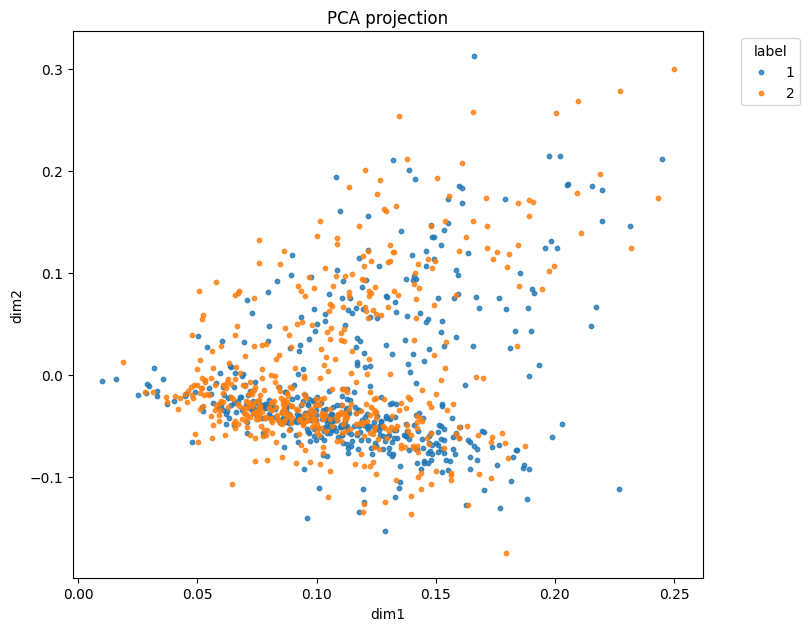

array([[ 0.11049801, -0.02953598],
       [ 0.19329677,  0.00916852],
       [ 0.12381569, -0.0854555 ],
       ...,
       [ 0.17582971,  0.12024662],
       [ 0.12398606, -0.05379112],
       [ 0.13085946,  0.11103919]], shape=(1000, 2))

In [18]:
plot_dimensionality_reduction(X_valid_tfidf, processed_valid['review_target'], method='PCA')

## PCA Visualization on Validation Data

The validation set shows similar clustering patterns to the training data, indicating that the TF-IDF features generalize well. The consistent separation between positive and negative reviews validates our feature engineering approach and suggests the model should perform similarly on unseen data.

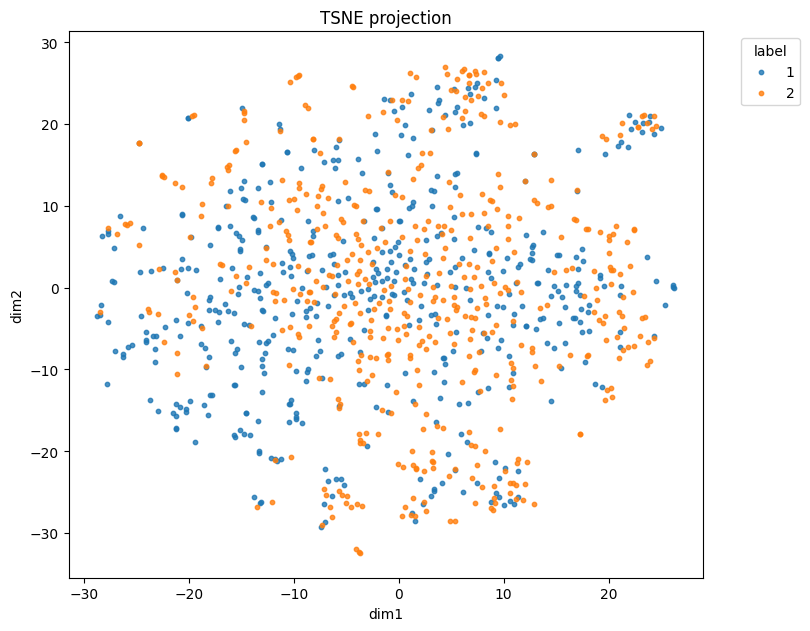

array([[ -3.1307783 , -17.791399  ],
       [ 17.719727  ,  -9.084358  ],
       [  2.5759785 , -27.256256  ],
       ...,
       [ 10.130042  ,   0.07198764],
       [-14.729359  ,  21.340534  ],
       [ 21.996363  ,   2.676641  ]], shape=(1000, 2), dtype=float32)

In [19]:
plot_dimensionality_reduction(X_valid_tfidf, processed_valid['review_target'], method='TSNE')

## t-SNE Visualization on Validation Data

The t-SNE plot for validation data maintains the distinct clusters observed in training, confirming that our feature representation is robust. This consistency across datasets is crucial for building reliable machine learning models that don't overfit to the training data.

loadِ valid and test dataset to apply transform using TF-IDF 


In [20]:
processed_test = pd.read_csv(r'data/processed/processed_test.csv', dtype=str, quoting=0)
processed_test.head()

,review_target,review_title,review_content,review_content_cleaned,review_title_cleaned
0,2,This is a great book,I must preface this by saying that I am not re...,must preface saying not religious but loved bo...,great book
1,1,Huge Disappointment.,"As a big time, long term Trevanian fan, I was ...",big time long term trevanian fan extremely dis...,huge disappointment
2,2,Wayne is tight but cant hang with Turk.,This album is hot as it wants to be. However C...,album hot want however cash money best album e...,wayne tight but cannot hang turk
3,2,Excellent,I read this book when I was in elementary scho...,read book elementary school probably fourth gr...,excellent
4,1,Not about Anusara,Although this book is touted on several Anusar...,although book touted several anusara web site ...,not anusara


In [21]:
processed_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_target           20000 non-null  str  
 1   review_title            19999 non-null  str  
 2   review_content          20000 non-null  str  
 3   review_content_cleaned  20000 non-null  str  
 4   review_title_cleaned    19926 non-null  str  
dtypes: str(5)
memory usage: 781.4 KB


In [22]:
X_test_tfidf = tfidf_vectorizer.transform(processed_test['review_content_cleaned'].astype(str))
print('Test TF-IDF shape:', X_test_tfidf.shape)

Test TF-IDF shape: (20000, 50000)


Visualize separability using dimensionality reduction (PCA and TSNE) for test dataset

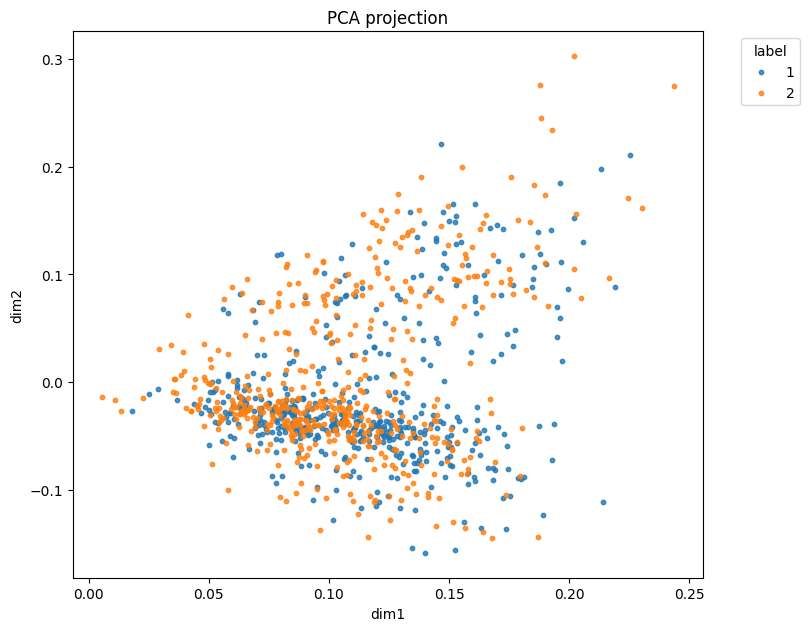

array([[ 0.08984002, -0.02979302],
       [ 0.10067524, -0.04033995],
       [ 0.16061181,  0.0787406 ],
       ...,
       [ 0.1028204 ,  0.06257252],
       [ 0.16038205, -0.08803981],
       [ 0.08443986, -0.05117571]], shape=(1000, 2))

In [23]:
plot_dimensionality_reduction(X_test_tfidf, processed_test['review_target'], method='PCA')

## PCA Visualization on Test Data

The test dataset exhibits comparable clustering to training and validation sets. This indicates that our TF-IDF feature engineering captures sentiment patterns that hold across different data splits, providing confidence in the model's ability to generalize to completely unseen reviews.

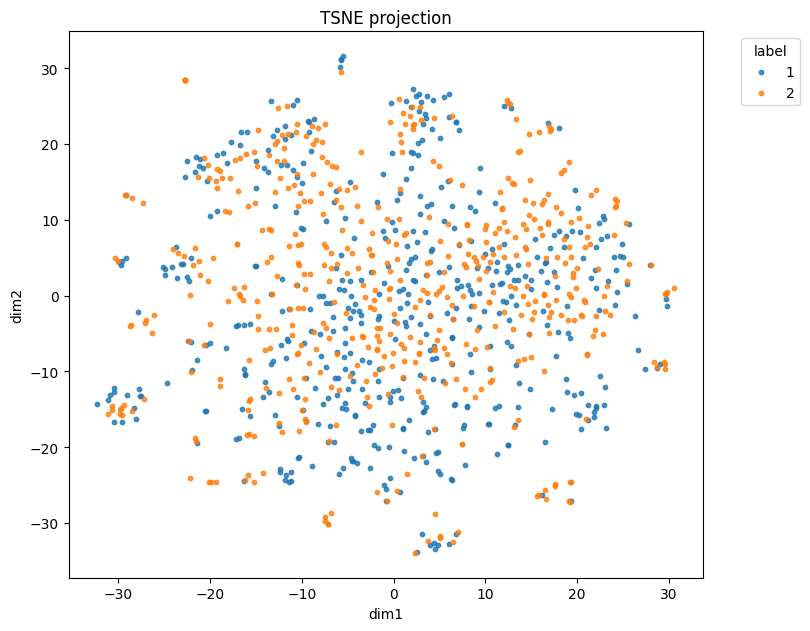

array([[ -5.9217315 ,   0.8796863 ],
       [ -2.5551841 , -22.730967  ],
       [ 16.255812  ,  -2.071274  ],
       ...,
       [  0.42086202, -25.785557  ],
       [-11.219019  ,  21.153608  ],
       [-16.39108   ,  -0.5604289 ]], shape=(1000, 2), dtype=float32)

In [24]:
plot_dimensionality_reduction(X_test_tfidf, processed_test['review_target'], method='TSNE')

## t-SNE Visualization on Test Data

The t-SNE visualization of test data shows well-defined clusters, reinforcing the effectiveness of our feature engineering pipeline. The maintained separation between sentiment classes across all datasets (train, validation, test) validates the quality of our TF-IDF vectorization and supports proceeding to model training.

Save `train dataset` after apply feature engineering

In [25]:
save(df_base='data/processed', df=feat_eng_train, df_name='feat_eng_train.csv')

Saved dataframe feat_eng_train.csv to data\processed\feat_eng_train.csv


{'csv': WindowsPath('data/processed/feat_eng_train.csv')}

save `tfidf_vectorizer` model, `X_train_tfidf`, and `y_train`

In [26]:
save(vectorizer_base='data/vectorizers', vectorizer=tfidf_vectorizer, vectorizer_name='tfidf_vectorizer.joblib', 
     vectors_base='data/vectorizers', vectors=X_train_tfidf, vectors_name="X_train_tfidf.npz",
     df_base='data/processed', df=feat_eng_train['review_target'], df_name='y_train.csv')

Saved dataframe y_train.csv to data\processed\y_train.csv
Saved vectorizer tfidf_vectorizer.joblib to data\vectorizers\tfidf_vectorizer.joblib
Saved vectors X_train_tfidf.npz to data\vectorizers\X_train_tfidf.npz


{'csv': WindowsPath('data/processed/y_train.csv'),
 'vectorizer': WindowsPath('data/vectorizers/tfidf_vectorizer.joblib'),
 'vectors': WindowsPath('data/vectorizers/X_train_tfidf.npz')}

save the `X_valid_tfidf` and `y_valid`

In [27]:
save(vectors_base='data/vectorizers', vectors=X_valid_tfidf, vectors_name="X_valid_tfidf.npz",
     df_base='data/processed', df=processed_valid['review_target'], df_name='y_valid.csv')

Saved dataframe y_valid.csv to data\processed\y_valid.csv
Saved vectors X_valid_tfidf.npz to data\vectorizers\X_valid_tfidf.npz


{'csv': WindowsPath('data/processed/y_valid.csv'),
 'vectors': WindowsPath('data/vectorizers/X_valid_tfidf.npz')}

save the `X_test_tfidf` and `y_test`

In [28]:
save(vectors_base='data/vectorizers', vectors=X_test_tfidf, vectors_name="X_test_tfidf.npz",
     df_base='data/processed', df=processed_test['review_target'], df_name='y_test.csv')

Saved dataframe y_test.csv to data\processed\y_test.csv
Saved vectors X_test_tfidf.npz to data\vectorizers\X_test_tfidf.npz


{'csv': WindowsPath('data/processed/y_test.csv'),
 'vectors': WindowsPath('data/vectorizers/X_test_tfidf.npz')}